London Carpool Connect - Data Generation Notebook

In this notebook I create the synthetic passenger and driver datasets used in my final year project.

I used synthetic data because real carpooling data would include sensitive information such as names, home locations, work locations and journey patterns. This lets me test the idea safely without collecting personal data from real people.


In [2]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import random
from faker import Faker

In [4]:
locations = pd.read_csv("/content/LondonLocationsDataset.csv")
locations.head()

,location,latitude,longitude,zone,type
0,Camden,51.5390,-0.1426,North,Residential/Leisure
1,Islington,51.5465,-0.1058,North,Residential
2,Stratford,51.5413,-0.0030,East,Residential/Business
3,Canary Wharf,51.5054,-0.0235,East,Business
4,Bank,51.5133,-0.0896,Central,Business


In [5]:
fake = Faker("en_GB")
random.seed(42)
np.random.seed(42)
Faker.seed(42)
# I set random seeds so the generated data is reproducible.
# This is important because I want the same outputs when I rerun the notebook for screenshots/results.

In [6]:
journey_times = ["07:00", "07:15", "07:30", "07:45","08:00", "08:15", "08:30", "08:45","09:00", "09:15", "09:30"]
vehicle_types = ["Petrol", "Diesel", "Hybrid", "Electric"]
passenger_flexibility = [5, 10, 15, 20]
driver_max_detours = [10, 15, 20, 25, 30]

In [7]:
def generate_passengers(num_passengers, locations_df):
    passengers = []

    for i in range(1, num_passengers + 1):
        origin = locations_df.sample(1).iloc[0]
        destination = locations_df.sample(1).iloc[0]

        # Make sure origin and destination are not the same
        while destination["location"] == origin["location"]:
            destination = locations_df.sample(1).iloc[0]

        passenger = {
            "passenger_id": f"P{i:03d}",
            "passenger_name": fake.name(),
            "origin": origin["location"],
            "origin_lat": origin["latitude"],
            "origin_lon": origin["longitude"],
            "origin_zone": origin["zone"],
            "destination": destination["location"],
            "destination_lat": destination["latitude"],
            "destination_lon": destination["longitude"],
            "destination_zone": destination["zone"],
            "preferred_time": random.choice(journey_times),
            "time_flexibility_mins": random.choice(passenger_flexibility),
            "max_pickup_distance_km": random.choice([0.5, 1.0, 1.5, 2.0]),
            "max_detour_mins": random.choice([10, 15, 20]),
            "requires_accessibility": random.choice([True, False, False, False]),
            "status": "unmatched"
        }

        passengers.append(passenger)

    return pd.DataFrame(passengers)

In [8]:
passengers = generate_passengers(50, locations)
passengers.head()

,passenger_id,passenger_name,origin,origin_lat,origin_lon,origin_zone,destination,destination_lat,destination_lon,destination_zone,preferred_time,time_flexibility_mins,max_pickup_distance_km,max_detour_mins,requires_accessibility,status
0,P001,William Jennings,Wimbledon,51.4214,-0.2064,South West,Camden,51.5390,-0.1426,North,09:30,5,0.5,20,False,unmatched
1,P002,Lesley Wilson-Newman,Bank,51.5133,-0.0896,Central,Canary Wharf,51.5054,-0.0235,East,07:45,10,1.0,20,True,unmatched
2,P003,Abdul Hopkins,Richmond,51.4613,-0.3037,South West,London Bridge,51.5079,-0.0877,Central,09:30,5,2.0,10,True,unmatched
3,P004,Mrs Lauren Green,Paddington,51.5154,-0.1755,West,Ealing,51.5130,-0.3089,West,07:15,10,1.0,20,True,unmatched
4,P005,Tina Foster,London Bridge,51.5079,-0.0877,Central,Waterloo,51.5036,-0.1143,Central,09:00,10,2.0,10,False,unmatched


In [9]:
def generate_drivers(num_drivers, locations_df):
    drivers = []

    for i in range(1, num_drivers + 1):
        origin = locations_df.sample(1).iloc[0]
        destination = locations_df.sample(1).iloc[0]

        # Make sure origin and destination are not the same
        while destination["location"] == origin["location"]:
            destination = locations_df.sample(1).iloc[0]

        driver = {
            "driver_id": f"D{i:03d}",
            "driver_name": fake.name(),
            "origin": origin["location"],
            "origin_lat": origin["latitude"],
            "origin_lon": origin["longitude"],
            "origin_zone": origin["zone"],
            "destination": destination["location"],
            "destination_lat": destination["latitude"],
            "destination_lon": destination["longitude"],
            "destination_zone": destination["zone"],
            "departure_time": random.choice(journey_times),
            "time_flexibility_mins": random.choice([5, 10, 15]),
            "seats_available": random.choice([1, 2, 3, 4]),
            "vehicle_type": random.choice(vehicle_types),
            "max_detour_mins": random.choice(driver_max_detours),
            "accepts_accessibility": random.choice([True, False, False]),
            "status": "available"
        }

        drivers.append(driver)

    return pd.DataFrame(drivers)

In [10]:
drivers = generate_drivers(20, locations)
drivers.head()

,driver_id,driver_name,origin,origin_lat,origin_lon,origin_zone,destination,destination_lat,destination_lon,destination_zone,departure_time,time_flexibility_mins,seats_available,vehicle_type,max_detour_mins,accepts_accessibility,status
0,D001,Joshua Stewart,Peckham,51.4742,-0.0697,South East,Wembley,51.5560,-0.2795,North West,08:00,10,3,Electric,30,False,available
1,D002,Philip Clarke,Hackney,51.5450,-0.0553,East,Greenwich,51.4826,0.0077,South East,08:45,5,2,Hybrid,15,True,available
2,D003,Henry O'Brien,Croydon,51.3762,-0.0982,South,Peckham,51.4742,-0.0697,South East,09:15,15,1,Hybrid,10,True,available
3,D004,Leon Davison,Tottenham,51.5888,-0.0726,North,London Bridge,51.5079,-0.0877,Central,09:15,10,2,Petrol,30,True,available
4,D005,Kayleigh Mitchell,Wimbledon,51.4214,-0.2064,South West,London Bridge,51.5079,-0.0877,Central,07:30,5,1,Diesel,25,True,available


In [11]:
passengers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   passenger_id            50 non-null     object 
 1   passenger_name          50 non-null     object 
 2   origin                  50 non-null     object 
 3   origin_lat              50 non-null     float64
 4   origin_lon              50 non-null     float64
 5   origin_zone             50 non-null     object 
 6   destination             50 non-null     object 
 7   destination_lat         50 non-null     float64
 8   destination_lon         50 non-null     float64
 9   destination_zone        50 non-null     object 
 10  preferred_time          50 non-null     object 
 11  time_flexibility_mins   50 non-null     int64  
 12  max_pickup_distance_km  50 non-null     float64
 13  max_detour_mins         50 non-null     int64  
 14  requires_accessibility  50 non-null     bool

In [12]:
passengers.head(10)

,passenger_id,passenger_name,origin,origin_lat,origin_lon,origin_zone,destination,destination_lat,destination_lon,destination_zone,preferred_time,time_flexibility_mins,max_pickup_distance_km,max_detour_mins,requires_accessibility,status
0,P001,William Jennings,Wimbledon,51.4214,-0.2064,South West,Camden,51.5390,-0.1426,North,09:30,5,0.5,20,False,unmatched
1,P002,Lesley Wilson-Newman,Bank,51.5133,-0.0896,Central,Canary Wharf,51.5054,-0.0235,East,07:45,10,1.0,20,True,unmatched
2,P003,Abdul Hopkins,Richmond,51.4613,-0.3037,South West,London Bridge,51.5079,-0.0877,Central,09:30,5,2.0,10,True,unmatched
3,P004,Mrs Lauren Green,Paddington,51.5154,-0.1755,West,Ealing,51.5130,-0.3089,West,07:15,10,1.0,20,True,unmatched
4,P005,Tina Foster,London Bridge,51.5079,-0.0877,Central,Waterloo,51.5036,-0.1143,Central,09:00,10,2.0,10,False,unmatched
5,P006,Nigel Edwards,Brixton,51.4627,-0.1140,South,Hackney,51.5450,-0.0553,East,09:15,15,0.5,10,False,unmatched
6,P007,Abdul Burton-Patterson,London Bridge,51.5079,-0.0877,Central,Southwark,51.5035,-0.0804,Central,08:15,15,1.0,10,False,unmatched
7,P008,Sarah Reed-Walsh,Hackney,51.5450,-0.0553,East,Lewisham,51.4613,-0.0105,South East,07:15,5,2.0,10,False,unmatched
8,P009,Miss Olivia Bryan,Westminster,51.4975,-0.1357,Central,Croydon,51.3762,-0.0982,South,08:15,15,0.5,20,False,unmatched
9,P010,Dr Lee Green,Westminster,51.4975,-0.1357,Central,Southwark,51.5035,-0.0804,Central,09:00,5,2.0,10,False,unmatched


In [13]:
drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   driver_id              20 non-null     object 
 1   driver_name            20 non-null     object 
 2   origin                 20 non-null     object 
 3   origin_lat             20 non-null     float64
 4   origin_lon             20 non-null     float64
 5   origin_zone            20 non-null     object 
 6   destination            20 non-null     object 
 7   destination_lat        20 non-null     float64
 8   destination_lon        20 non-null     float64
 9   destination_zone       20 non-null     object 
 10  departure_time         20 non-null     object 
 11  time_flexibility_mins  20 non-null     int64  
 12  seats_available        20 non-null     int64  
 13  vehicle_type           20 non-null     object 
 14  max_detour_mins        20 non-null     int64  
 15  accepts_

In [14]:
drivers.head(10)

,driver_id,driver_name,origin,origin_lat,origin_lon,origin_zone,destination,destination_lat,destination_lon,destination_zone,departure_time,time_flexibility_mins,seats_available,vehicle_type,max_detour_mins,accepts_accessibility,status
0,D001,Joshua Stewart,Peckham,51.4742,-0.0697,South East,Wembley,51.5560,-0.2795,North West,08:00,10,3,Electric,30,False,available
1,D002,Philip Clarke,Hackney,51.5450,-0.0553,East,Greenwich,51.4826,0.0077,South East,08:45,5,2,Hybrid,15,True,available
2,D003,Henry O'Brien,Croydon,51.3762,-0.0982,South,Peckham,51.4742,-0.0697,South East,09:15,15,1,Hybrid,10,True,available
3,D004,Leon Davison,Tottenham,51.5888,-0.0726,North,London Bridge,51.5079,-0.0877,Central,09:15,10,2,Petrol,30,True,available
4,D005,Kayleigh Mitchell,Wimbledon,51.4214,-0.2064,South West,London Bridge,51.5079,-0.0877,Central,07:30,5,1,Diesel,25,True,available
5,D006,Oliver Edwards-Matthews,Ealing,51.5130,-0.3089,West,Paddington,51.5154,-0.1755,West,09:15,5,1,Petrol,25,False,available
6,D007,Victor Patel,Chelsea,51.4875,-0.1687,West,Wembley,51.5560,-0.2795,North West,09:15,15,3,Hybrid,15,False,available
7,D008,Eric O'Neill,Tottenham,51.5888,-0.0726,North,Ealing,51.5130,-0.3089,West,08:15,5,3,Electric,15,False,available
8,D009,Charlotte Haynes,Shoreditch,51.5245,-0.0780,East,Chelsea,51.4875,-0.1687,West,09:30,10,4,Hybrid,10,True,available
9,D010,Martyn Wilson,Ealing,51.5130,-0.3089,West,Whitechapel,51.5190,-0.0594,East,08:45,15,1,Petrol,30,True,available


In [15]:
passengers[passengers["origin"] == passengers["destination"]]

,passenger_id,passenger_name,origin,origin_lat,origin_lon,origin_zone,destination,destination_lat,destination_lon,destination_zone,preferred_time,time_flexibility_mins,max_pickup_distance_km,max_detour_mins,requires_accessibility,status


In [16]:
drivers[drivers["origin"] == drivers["destination"]]

,driver_id,driver_name,origin,origin_lat,origin_lon,origin_zone,destination,destination_lat,destination_lon,destination_zone,departure_time,time_flexibility_mins,seats_available,vehicle_type,max_detour_mins,accepts_accessibility,status


In [17]:
passengers.to_csv("passengers.csv", index=False)
drivers.to_csv("drivers.csv", index=False)

<Axes: title={'center': 'Passenger Origins by London Zone'}, xlabel='origin_zone'>

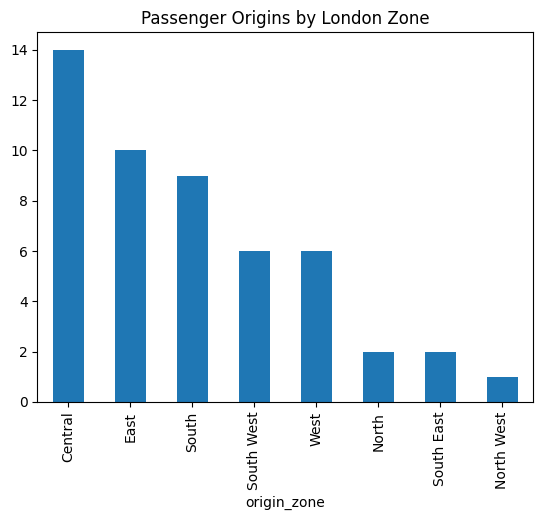

In [18]:
passengers["origin_zone"].value_counts().plot(kind="bar", title="Passenger Origins by London Zone")

<Axes: title={'center': 'Driver Vehicle Types'}, xlabel='vehicle_type'>

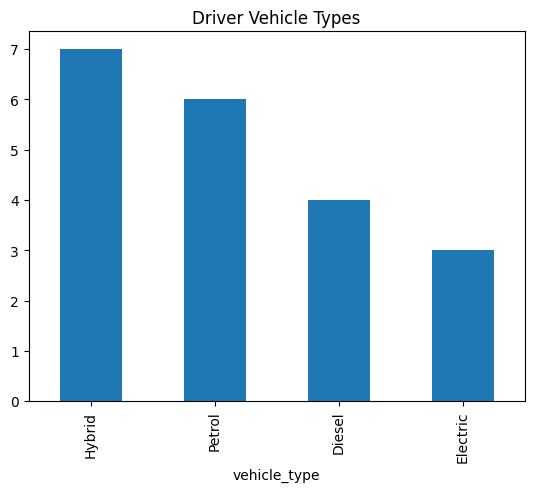

In [19]:
drivers["vehicle_type"].value_counts().plot(kind="bar", title="Driver Vehicle Types")